In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
import seaborn as sns
from scipy.stats import pearsonr 
from scipy.stats import shapiro 
from scipy.stats import linregress
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from OceanDataStore import OceanDataCatalog 
from nemo_cookbook import NEMODataTree  
from matplotlib.patches import Rectangle

In [4]:
def select_by_lonlat(ds, lon_target, lat_target):
    lat = ds['gphit'].values
    lon = ds['glamt'].values
    distance = np.sqrt((lat - lat_target)**2 + (lon - lon_target)**2)
    y_idx, x_idx = np.unravel_index(np.argmin(distance), distance.shape)
    print('x index =', x_idx)
    print('y index =', y_idx)
    return (y_idx, x_idx)


In [5]:
## Start with our data

years = np.arange(1990, 2025)
max_temp = xr.open_dataset('../../CORRELATION/max_ts_0.25.nc')['tos_con']
min_temp = xr.open_dataset('../../CORRELATION/min_ts_0.25.nc')['tos_con']



x index = 119
y index = 304


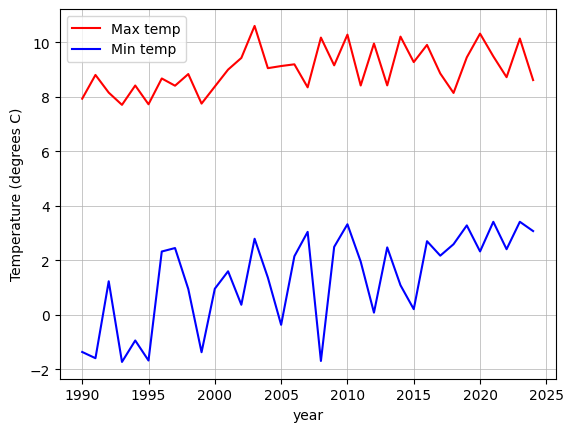

In [11]:
## Consider 59W, 60N (retreating ice edge)

j_idx, i_idx = select_by_lonlat(max_temp, -59.0, 60.0)
max_ts = max_temp.isel(j=j_idx, i=i_idx).values
min_ts = min_temp.isel(j=j_idx, i=i_idx).values

fig, ax = plt.subplots()
ax.plot(years, max_ts, color = 'r', label = 'Max temp')
ax.plot(years, min_ts, color = 'b', label = 'Min temp')

ax.set_xlabel('year')
ax.set_ylabel('Temperature (degrees C)')
ax.legend(loc = 'best')
ax.grid(True, which='both', linewidth=0.5)

plt.show()

In [16]:
# Now consdier NOAA data 

ds = xr.open_dataset('sst.week.mean.nc')['sst'].sel(lat = 60.0, lon = 301.0, method = 'nearest')

In [18]:
ds

<xarray.DataArray 'sst' (time: 2318)> Size: 9kB
[2318 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 19kB 1981-09-06 1981-09-13 ... 2026-02-01
    lat      float32 4B 60.12
    lon      float32 4B 301.1
Attributes:
    long_name:      Weekly Mean of Sea Surface Temperature
    units:          degC
    valid_range:    [-3. 45.]
    precision:      2.0
    dataset:        NOAA High-resolution Blended Analysis
    var_desc:       Sea Surface Temperature
    level_desc:     Surface
    statistic:      Weekly Mean
    parent_stat:    Individual Observations
    standard_name:  sea_surface_temperature
    actual_range:   [-1.8000001 32.14     ]

In [24]:
min_region = ds.sel(time = ds['time'].dt.month.isin([2, 3, 4]))
max_region = ds.sel(time = ds['time'].dt.month.isin([8, 9, 10]))
print('1')
NOAAmin_temp = ((min_region.groupby('time.year')).min(dim='time')).compute()
print('2')
NOAAmax_temp = ((max_region.groupby('time.year')).max(dim='time')).compute()

1
2


In [35]:
NOAAmin_ts = NOAAmin_temp.sel(year = slice(1990, 2024))
NOAAmax_ts = NOAAmax_temp.sel(year = slice(1990, 2024))

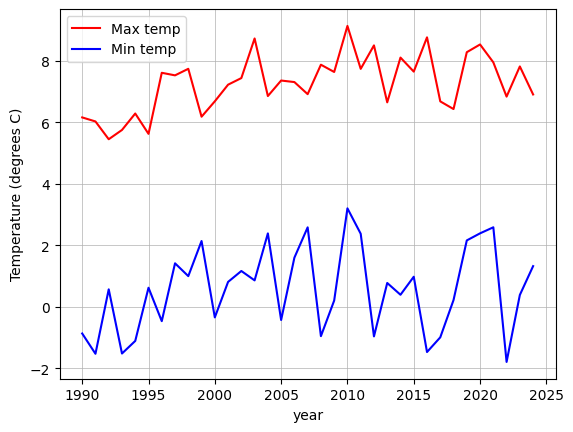

In [36]:
fig, ax = plt.subplots()
ax.plot(years, NOAAmax_ts, color = 'r', label = 'Max temp')
ax.plot(years, NOAAmin_ts, color = 'b', label = 'Min temp')

ax.set_xlabel('year')
ax.set_ylabel('Temperature (degrees C)')
ax.legend(loc = 'best')
ax.grid(True, which='both', linewidth=0.5)

plt.show()

In [33]:
NOAAmax_ts

array([], dtype=float32)

In [30]:
years

array([1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023, 2024])